In [21]:
import re
import math
import pandas as pd
import numpy as np

In [22]:
def normalise(text: str) -> str:
    """
    Normalise a string for comparison by:
      1. Lowercasing everything
      2. Removing all punctuation
      3. Collapsing multiple whitespace characters into a single space
      4. Stripping leading/trailing whitespace

    Args:
        text: Any raw string (model output or reference answer)

    Returns:
        A cleaned, lowercase string ready for substring matching
    """
    # Step 1: lowercase
    text = text.lower()

    # Step 2: remove punctuation
    # re.sub replaces all characters that match the pattern with ""
    # [^\w\s] means: any character that is NOT a word character (\w = letters/digits/underscore)
    # and NOT a whitespace character (\s)
    text = re.sub(r"[^\w\s]", "", text)

    # Step 3: collapse multiple spaces/tabs/newlines into a single space
    text = re.sub(r"\s+", " ", text)

    # Step 4: strip leading and trailing whitespace
    text = text.strip()

    return text

def answer_found_in_output(answer_variants: list[str], normalised_output: str) -> bool:
    """
    Check whether any of the provided answer variants appears as a substring
    in the (already normalised) model output.

    Args:
        answer_variants: A list of acceptable answer strings (e.g. ["knowledge distillation",
                         "distillation", "model distillation"]). These will be normalised
                         inside this function before matching.
        normalised_output: The model's output string, already normalised via normalise().

    Returns:
        True if at least one variant is found in the output, False otherwise.
    """
    for variant in answer_variants:
        # Normalise the reference variant with the same function
        # so the comparison is apples-to-apples
        normalised_variant = normalise(variant)
    
        # Check if the variant appears anywhere inside the output string
        if normalised_variant in normalised_output:
            return True  # Found a match — no need to check the rest

    # If we made it through the whole list without finding anything, return False
    return False


def score_single_output(
    model_output: str,
    faithful_answers: list[str],
    parametric_answers: list[str],
) -> str:
    """
    Classify a single model output as faithful, parametric, or ambiguous.

    A model output is:
      - "faithful"   if it contains a faithful answer variant (followed context)
      - "parametric" if it contains a parametric answer variant (recalled from memory)
      - "ambiguous"  if it contains BOTH, or NEITHER — excluded from CS scoring

    Args:
        model_output:      The raw string output from the model (will be normalised here)
        faithful_answers:  List of strings the model should say if it followed the context
                           (SC1: perturbed_answer variants | SC2: answer string wrapped in a list)
        parametric_answers: List of strings the model says if it relies on memory
                           (SC1: correct_answer variants | SC2: memory_answer wrapped in a list)

    Returns:
        One of: "faithful", "parametric", "ambiguous"
    """
    # Normalise the model output once here, then reuse it for both checks
    norm_output = normalise(model_output)

    # Check both directions using the matching function from Step 1
    found_faithful   = answer_found_in_output(faithful_answers,   norm_output)
    found_parametric = answer_found_in_output(parametric_answers, norm_output)

    # decide the label based on what was (and wasn't) found
    if found_faithful and not found_parametric:
        return "faithful"

    elif found_parametric and not found_faithful:
        return "parametric"

    else:
        # Either both were found (model hedged / listed both)
        # or neither was found (model said something completely different)
        # → we can't cleanly classify this, so exclude it
        return "ambiguous"

def aggregate_checkpoint_scores(
    model_outputs: list[str],
    faithful_answers_per_row: list[list[str]],
    parametric_answers_per_row: list[list[str]],
) -> dict:
    """
    Score every row for one checkpoint and aggregate into summary statistics.

    For each row, we call score_single_output() to get a label.
    We then count faithful / parametric / ambiguous, compute the CS score,
    and compute a 95% confidence interval using the standard error of a proportion.

    Args:
        model_outputs:              List of raw model output strings, one per row.
        faithful_answers_per_row:   List of lists — for each row, the list of strings
                                    the model should say if it followed the context.
        parametric_answers_per_row: List of lists — for each row, the list of strings
                                    the model would say if it relied on memory.

    Returns:
        A dictionary with keys:
            cs_score, cs_lower_95, cs_upper_95,
            n_faithful, n_parametric, n_ambiguous, n_total
    """
    # Counters — we increment these as we loop through the rows
    n_faithful   = 0
    n_parametric = 0
    n_ambiguous  = 0

    # Total number of rows passed in (including ambiguous)
    n_total = len(model_outputs)

    # Loop through every row, score it, and update the appropriate counter
    for output, faithful_ans, parametric_ans in zip(
        model_outputs,
        faithful_answers_per_row,
        parametric_answers_per_row,
    ):
        label = score_single_output(output, faithful_ans, parametric_ans)

        if label == "faithful":
            n_faithful += 1
        elif label == "parametric":
            n_parametric += 1
        else:
            # Covers both "ambiguous" cases (both found, or neither found)
            n_ambiguous += 1

    # --- CS score ---
    # Only score the rows we could cleanly classify
    n_scored = n_faithful + n_parametric

    # Guard against division by zero (e.g. if every single row was ambiguous)
    if n_scored == 0:
        return {
            "cs_score":    None,
            "cs_lower_95": None,
            "cs_upper_95": None,
            "n_faithful":  n_faithful,
            "n_parametric": n_parametric,
            "n_ambiguous": n_ambiguous,
            "n_total":     n_total,
        }

    # The proportion of scored rows that were faithful to the context
    cs = n_faithful / n_scored

    # --- 95% confidence interval ---
    # With 95% confidence, the true CS score (if we scored every possible row) would be between cs_lower and cs_upper
    # Standard error of a proportion
    se = math.sqrt((cs * (1 - cs)) / n_scored)

    # Lower and upper bounds — clipped to [0, 1] since a proportion can't exceed those
    cs_lower = max(0.0, cs - 1.96 * se)
    cs_upper = min(1.0, cs + 1.96 * se)

    return {
        "cs_score":     round(cs, 4),
        "cs_lower_95":  round(cs_lower, 4),
        "cs_upper_95":  round(cs_upper, 4),
        "n_faithful":   n_faithful,
        "n_parametric": n_parametric,
        "n_ambiguous":  n_ambiguous,
        "n_total":      n_total,
    }
    

def mean_perplexity(ppl_values: list) -> float:
    """Compute geometric mean perplexity, ignoring NaN and non-positive values."""
    valid_logs = []

    for raw in ppl_values:
        try:
            value = float(raw)
        except (ValueError, TypeError):
            continue
        if math.isnan(value) or value <= 0:
            continue
        valid_logs.append(math.log(value))

    if len(valid_logs) == 0:
        return None

    return math.exp(sum(valid_logs) / len(valid_logs))

In [23]:
# Checkpoint steps
STEPS = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130]
# Add BM25 output column 
BM25_OUTPUT_COL = "output_checkpoint_bm25"

def unify_columns(df: pd.DataFrame, sub_condition: str) -> pd.DataFrame:
    """
    Rename SC2 answer columns to match SC1 structure.
    After this, both dataframes have perturbed_answer and correct_answer as lists of strings.
    """

    if sub_condition == "sc2":
        df = df.copy()
        df["perturbed_answer"] = df["answer"].apply(lambda x: [x])
        df["correct_answer"] = df["memory_answer"].apply(lambda x: [x])
        df = df.drop(columns=["answer", "memory_answer"])

    return df

def load_and_prepare(path: str, sub_condition: str) -> tuple[pd.DataFrame, list[int]]:
    """
    Load a parquet file, unify columns, and extract checkpoint step numbers
    from the output column names.

    Returns the prepared dataframe and a sorted list of step numbers,
    e.g. [0, 10, 20, 30, ..., 130] where 0 corresponds to output_base_model.
    """
    df = pd.read_parquet(path)
    df = unify_columns(df, sub_condition)

    # Find all columns that contain model outputs, e.g. "output_checkpoint_10"
    # and "output_base_model". We identify them by the "output_" prefix.
    output_cols = [col for col in df.columns if col.startswith("output_checkpoint")]

    # Extract the step number from each column name.
    # "output_base_model" → step 0
    # "output_checkpoint_10" → step 10
    steps = []
    for col in output_cols:
        if "base_model" in col:
            steps.append(0)
        else:
            # Pull the number out of e.g. "output_checkpoint_10"
            # regex looks for digits at the end of the string and captures them
            match = re.search(r"(\d+)$", col)
            if match:
                steps.append(int(match.group(1)))

    steps = sorted(steps)

    return df, steps

def step_to_output_col(step: int) -> str:
    """Return the output column name for a given step number."""
    if step == 0:
        return "output_base_model"
    return f"output_checkpoint_{step}"

def step_to_ppl_col(step: int) -> str:
    """Return the perplexity column name for a given step number."""
    if step == 0:
        return "output_base_model_ppl"
    return f"output_checkpoint_{step}_ppl"

def load_and_prepare(path: str, sub_condition: str) -> pd.DataFrame:
    """Load a parquet file and unify columns."""
    df = pd.read_parquet(path)
    df = unify_columns(df, sub_condition)
    return df

=== SC1 — NLP Domain ===
         model   display_name  sort_order  cs_score  cs_lower_95  cs_upper_95  n_faithful  n_parametric  n_ambiguous  n_total  mean_ppl
    base_model     Base Model           0    0.5735       0.4904       0.6567          78            58           44      180  2.905363
 checkpoint_10  Checkpoint 10          10    0.8614       0.8089       0.9140         143            23           14      180  4.569631
 checkpoint_20  Checkpoint 20          20    0.8631       0.8111       0.9151         145            23           12      180  4.154343
 checkpoint_30  Checkpoint 30          30    0.8810       0.8320       0.9299         148            20           12      180  4.259233
 checkpoint_40  Checkpoint 40          40    0.9118       0.8691       0.9544         155            15           10      180  4.571082
 checkpoint_50  Checkpoint 50          50    0.8802       0.8310       0.9295         147            20           13      180  4.408469
 checkpoint_60  Checkpo

/var/folders/7j/b6vvq5f56ndfbxtx0q0tgzxw0000gn/T/ipykernel_36788/4057229505.py:246: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha="right")


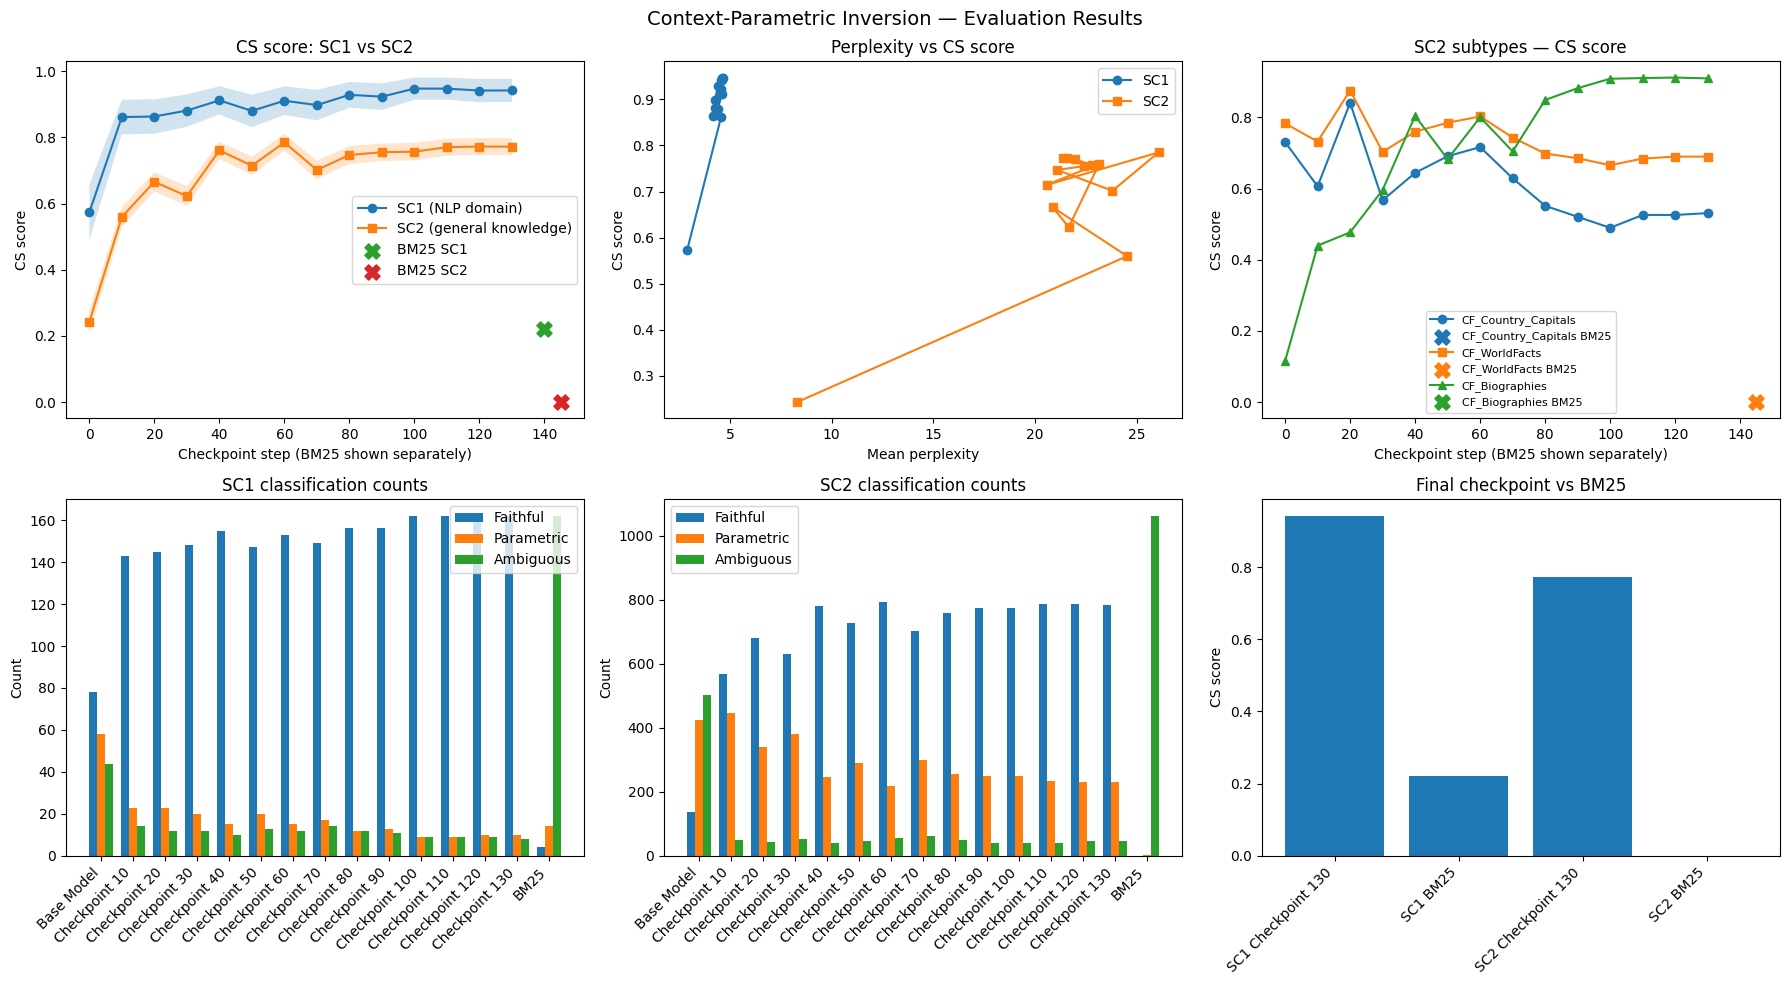

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# ── Paths ────────────────────────────────────────────────────────────────────
# SC1_PATH = "evaluation_study/data/sc1_output.parquet"
# SC2_PATH = "evaluation_study/data/sc2_output.parquet"
SC1_PATH = "data/sc1_output.parquet"
SC2_PATH = "data/sc2_output.parquet"

# ── Load data ─────────────────────────────────────────────────────────────────
sc1 = load_and_prepare(SC1_PATH, "sc1")
sc2 = load_and_prepare(SC2_PATH, "sc2")

# ── Compute metrics for one dataframe across all checkpoints ──────────────────
def compute_results(df: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for step in STEPS:
        output_col = step_to_output_col(step)
        ppl_col    = step_to_ppl_col(step)

        # Skip missing columns safely
        if output_col not in df.columns:
            continue

        scores = aggregate_checkpoint_scores(
            model_outputs              = df[output_col].tolist(),
            faithful_answers_per_row   = df["perturbed_answer"].tolist(),
            parametric_answers_per_row = df["correct_answer"].tolist(),
        )

        scores["model"] = "base_model" if step == 0 else f"checkpoint_{step}"
        scores["display_name"] = "Base Model" if step == 0 else f"Checkpoint {step}"
        scores["sort_order"] = step

        if ppl_col in df.columns:
            scores["mean_ppl"] = mean_perplexity(df[ppl_col].tolist())
        else:
            scores["mean_ppl"] = np.nan


        rows.append(scores)

    # BM25 baseline output
    if BM25_OUTPUT_COL in df.columns:
        scores = aggregate_checkpoint_scores(
            model_outputs=df[BM25_OUTPUT_COL].fillna("").astype(str).tolist(),
            faithful_answers_per_row=df["perturbed_answer"].tolist(),
            parametric_answers_per_row=df["correct_answer"].tolist(),
        )

        scores["model"] = "bm25"
        scores["display_name"] = "BM25"
        scores["sort_order"] = 999
        scores["mean_ppl"] = np.nan   # BM25 has no perplexity

        rows.append(scores)
        
    results = pd.DataFrame(rows)

    # Reorder columns nicely
    # results = results[["step", "cs_score", "cs_lower_95", "cs_upper_95",
    #                     "n_faithful", "n_parametric", "n_ambiguous", "n_total",
    #                     "mean_ppl"]]
    results = results[
        [
            "model",
            "display_name",
            "sort_order",
            "cs_score",
            "cs_lower_95",
            "cs_upper_95",
            "n_faithful",
            "n_parametric",
            "n_ambiguous",
            "n_total",
            "mean_ppl",
        ]
    ].sort_values("sort_order").reset_index(drop=True)

    return results


results_sc1 = compute_results(sc1)
results_sc2 = compute_results(sc2)



# ── Also break SC2 down by sub-type ──────────────────────────────────────────
SC2_SUBTYPES = {
    "CF_Country_Capitals": "sc2_1_",
    "CF_WorldFacts": "sc2_2_",
    "CF_Biographies": "sc2_3_",
}

results_sc2_subtypes = {}
for name, prefix in SC2_SUBTYPES.items():
    subset = sc2[sc2["id"].str.startswith(prefix)].reset_index(drop=True)
    results_sc2_subtypes[name] = compute_results(subset)

# ── Save to CSV ───────────────────────────────────────────────────────────────
results_sc1.to_csv("results_sc1.csv", index=False)
results_sc2.to_csv("results_sc2.csv", index=False)
for name, df_sub in results_sc2_subtypes.items():
    df_sub.to_csv(f"results_{name}.csv", index=False)

# ── Print tables ──────────────────────────────────────────────────────────────
print("=== SC1 — NLP Domain ===")
print(results_sc1.to_string(index=False))

print("\n=== SC2 — General Knowledge (overall) ===")
print(results_sc2.to_string(index=False))

for name, df_sub in results_sc2_subtypes.items():
    print(f"\n=== SC2 — {name} ===")
    print(df_sub.to_string(index=False))

# ── Prepare checkpoint-only subsets for line plots ───────────────────────────
results_sc1_ckpt = results_sc1[results_sc1["model"] != "bm25"].copy()
results_sc2_ckpt = results_sc2[results_sc2["model"] != "bm25"].copy()

# recover numeric step for plotting
def extract_step(model_name: str) -> int:
    if model_name == "base_model":
        return 0
    match = re.search(r"checkpoint_(\d+)", model_name)
    return int(match.group(1)) if match else -1

results_sc1_ckpt["step"] = results_sc1_ckpt["model"].apply(extract_step)
results_sc2_ckpt["step"] = results_sc2_ckpt["model"].apply(extract_step)

# for name in results_sc2_subtypes:
for name in list(results_sc2_subtypes.keys()):
    df_sub = results_sc2_subtypes[name]
    df_sub_ckpt = df_sub[df_sub["model"] != "bm25"].copy()
    df_sub_ckpt["step"] = df_sub_ckpt["model"].apply(extract_step)
    results_sc2_subtypes[name + "_ckpt"] = df_sub_ckpt

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Context-Parametric Inversion — Evaluation Results", fontsize=14)

# --- Plot 1: CS score SC1 vs SC2 (checkpoints as lines, BM25 as point) ---
ax = axes[0, 0]
ax.plot(results_sc1_ckpt["step"], results_sc1_ckpt["cs_score"], marker="o", label="SC1 (NLP domain)")
ax.fill_between(results_sc1_ckpt["step"], results_sc1_ckpt["cs_lower_95"], results_sc1_ckpt["cs_upper_95"], alpha=0.2)

ax.plot(results_sc2_ckpt["step"], results_sc2_ckpt["cs_score"], marker="s", label="SC2 (general knowledge)")
ax.fill_between(results_sc2_ckpt["step"], results_sc2_ckpt["cs_lower_95"], results_sc2_ckpt["cs_upper_95"], alpha=0.2)

# BM25 points
if "bm25" in results_sc1["model"].values:
    bm25_sc1 = results_sc1[results_sc1["model"] == "bm25"].iloc[0]
    ax.scatter([140], [bm25_sc1["cs_score"]], s=120, marker="X", label="BM25 SC1")

if "bm25" in results_sc2["model"].values:
    bm25_sc2 = results_sc2[results_sc2["model"] == "bm25"].iloc[0]
    ax.scatter([145], [bm25_sc2["cs_score"]], s=120, marker="X", label="BM25 SC2")

ax.set_title("CS score: SC1 vs SC2")
ax.set_xlabel("Checkpoint step (BM25 shown separately)")
ax.set_ylabel("CS score")
ax.legend()

# --- Plot 2: Perplexity vs CS score (checkpoint models only) ---
ax = axes[0, 1]
ax.plot(results_sc1_ckpt["mean_ppl"], results_sc1_ckpt["cs_score"], marker="o", label="SC1")
ax.plot(results_sc2_ckpt["mean_ppl"], results_sc2_ckpt["cs_score"], marker="s", label="SC2")
ax.set_title("Perplexity vs CS score")
ax.set_xlabel("Mean perplexity")
ax.set_ylabel("CS score")
ax.legend()

# --- Plot 3: SC2 subtypes CS score (checkpoints as lines + BM25 points) ---
ax = axes[0, 2]
markers = ["o", "s", "^"]
for (name, _), marker in zip(SC2_SUBTYPES.items(), markers):
    sub_ckpt = results_sc2_subtypes[name + "_ckpt"]
    ax.plot(sub_ckpt["step"], sub_ckpt["cs_score"], marker=marker, label=name)

    sub_all = results_sc2_subtypes[name]
    if "bm25" in sub_all["model"].values:
        bm25_row = sub_all[sub_all["model"] == "bm25"].iloc[0]
        ax.scatter([145], [bm25_row["cs_score"]], s=120, marker="X", label=f"{name} BM25")

ax.set_title("SC2 subtypes — CS score")
ax.set_xlabel("Checkpoint step (BM25 shown separately)")
ax.set_ylabel("CS score")
ax.legend(fontsize=8)

# --- Plot 4: Faithful / Parametric / Ambiguous counts for SC1 ---
ax = axes[1, 0]
x_labels = results_sc1["display_name"]
x = np.arange(len(x_labels))
w = 0.25

ax.bar(x - w, results_sc1["n_faithful"], width=w, label="Faithful")
ax.bar(x,     results_sc1["n_parametric"], width=w, label="Parametric")
ax.bar(x + w, results_sc1["n_ambiguous"], width=w, label="Ambiguous")

ax.set_title("SC1 classification counts")
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=45, ha="right")
ax.set_ylabel("Count")
ax.legend()

# --- Plot 5: Faithful / Parametric / Ambiguous counts for SC2 ---
ax = axes[1, 1]
x_labels = results_sc2["display_name"]
x = np.arange(len(x_labels))

ax.bar(x - w, results_sc2["n_faithful"], width=w, label="Faithful")
ax.bar(x,     results_sc2["n_parametric"], width=w, label="Parametric")
ax.bar(x + w, results_sc2["n_ambiguous"], width=w, label="Ambiguous")

ax.set_title("SC2 classification counts")
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=45, ha="right")
ax.set_ylabel("Count")
ax.legend()

# --- Plot 6: BM25 vs final checkpoint comparison ---
ax = axes[1, 2]

comparison_rows = []

# SC1
final_sc1 = results_sc1[results_sc1["model"] == "checkpoint_130"]
if not final_sc1.empty:
    comparison_rows.append(("SC1 Checkpoint 130", final_sc1.iloc[0]["cs_score"]))
bm25_sc1_rows = results_sc1[results_sc1["model"] == "bm25"]
if not bm25_sc1_rows.empty:
    comparison_rows.append(("SC1 BM25", bm25_sc1_rows.iloc[0]["cs_score"]))

# SC2
final_sc2 = results_sc2[results_sc2["model"] == "checkpoint_130"]
if not final_sc2.empty:
    comparison_rows.append(("SC2 Checkpoint 130", final_sc2.iloc[0]["cs_score"]))
bm25_sc2_rows = results_sc2[results_sc2["model"] == "bm25"]
if not bm25_sc2_rows.empty:
    comparison_rows.append(("SC2 BM25", bm25_sc2_rows.iloc[0]["cs_score"]))

if comparison_rows:
    labels, values = zip(*comparison_rows)
    ax.bar(labels, values)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_title("Final checkpoint vs BM25")
    ax.set_ylabel("CS score")
else:
    ax.set_title("Final checkpoint vs BM25")
    ax.text(0.5, 0.5, "No BM25 data found", ha="center", va="center")

plt.tight_layout()
plt.show()

In [25]:
# Check the distribution of ppl values at step 0 for SC2
ppl_col = "output_base_model_ppl"
ppl_values = pd.to_numeric(sc2[ppl_col], errors="coerce")
print(ppl_values.describe())
print(f"Rows with ppl > 1000: {(ppl_values > 1000).sum()}")

count      1064.000000
mean       1179.161434
std       14092.598756
min           1.078125
25%           1.560547
50%           2.429688
75%           4.570312
max      323584.000000
Name: output_base_model_ppl, dtype: float64
Rows with ppl > 1000: 165


In [26]:
def count_exact_matches(df: pd.DataFrame, step: int) -> dict:
    output_col = step_to_output_col(step)
    
    n_exact_faithful   = 0
    n_exact_parametric = 0

    for _, row in df.iterrows():
        output = row[output_col].lower().strip()
        
        faithful_match   = any(output == v.lower().strip() for v in row["perturbed_answer"])
        parametric_match = any(output == v.lower().strip() for v in row["correct_answer"])
        
        if faithful_match:
            n_exact_faithful += 1
        if parametric_match:
            n_exact_parametric += 1

    return {
        "n_exact_faithful":   n_exact_faithful,
        "n_exact_parametric": n_exact_parametric,
        "n_total":            len(df),
    }

# Run it for both datasets at every step
for step in STEPS:
    r = count_exact_matches(sc1, step)
    print(f"Step {step:>3} | SC1 | exact faithful: {r['n_exact_faithful']} | exact parametric: {r['n_exact_parametric']} | total: {r['n_total']}")

print()

for step in STEPS:
    r = count_exact_matches(sc2, step)
    print(f"Step {step:>3} | SC2 | exact faithful: {r['n_exact_faithful']} | exact parametric: {r['n_exact_parametric']} | total: {r['n_total']}")

Step   0 | SC1 | exact faithful: 5 | exact parametric: 0 | total: 180
Step  10 | SC1 | exact faithful: 132 | exact parametric: 24 | total: 180
Step  20 | SC1 | exact faithful: 133 | exact parametric: 23 | total: 180
Step  30 | SC1 | exact faithful: 129 | exact parametric: 21 | total: 180
Step  40 | SC1 | exact faithful: 131 | exact parametric: 14 | total: 180
Step  50 | SC1 | exact faithful: 128 | exact parametric: 19 | total: 180
Step  60 | SC1 | exact faithful: 123 | exact parametric: 14 | total: 180
Step  70 | SC1 | exact faithful: 129 | exact parametric: 16 | total: 180
Step  80 | SC1 | exact faithful: 132 | exact parametric: 11 | total: 180
Step  90 | SC1 | exact faithful: 131 | exact parametric: 12 | total: 180
Step 100 | SC1 | exact faithful: 134 | exact parametric: 8 | total: 180
Step 110 | SC1 | exact faithful: 138 | exact parametric: 8 | total: 180
Step 120 | SC1 | exact faithful: 143 | exact parametric: 9 | total: 180
Step 130 | SC1 | exact faithful: 142 | exact parametric: 